In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
# Este paquete me permite implementar un modelo de Naibe Bayes tipo Gaussian

from sklearn.model_selection import train_test_split
# Esto me permite dividir los datos en entrenamiento y testeo

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
# Estos paquetes me permiten evaluar que tan bien aprendio el modelo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
base=pd.read_csv('/content/drive/MyDrive/Semestre 8/Analitica de negocios/LinkedIn_RDB_three.csv')
base.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,job_id,title,description,pay_period,work_type,job_location,applies,remote_allowed,views,level,sponsored,compensation,job_domain,company_id,ben_pack_id
0,903408693,Office Associate,Provide clerical and administrative support to...,YEARLY,Full-time,"Albany, GA",5,False,49,NaN,True,"$42,000.00",Administration,3894635,1.0
1,1029078768,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,HOURLY,Part-time,"Muskegon, MI",0,False,4,NaN,False,"$104,000.00",Healthcare,61469,1.0
2,1657978824,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",MONTHLY,Contract,"Texas, United States",0,True,0,NaN,False,"$144,000.00",Other,89350959,1.0
3,2148434033,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",YEARLY,Contract,"Phoenix, AZ",0,False,0,Associate,False,"$65,000.00",Human Resources,1082195,1.0
4,2148434586,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,YEARLY,Full-time,"New Hampshire, United States",0,False,0,Mid-Senior level,False,"$170,976.00",Information Technology,2780388,113.0


In [ ]:
base.info()
#La base tiene 15 columnas 6328 filas
base.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6328 entries, 0 to 6327
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   job_id          6328 non-null   int64  
 1   title           6328 non-null   object 
 2   description     6328 non-null   object 
 3   pay_period      6328 non-null   object 
 4   work_type       6328 non-null   object 
 5   job_location    6328 non-null   object 
 6   applies         6328 non-null   int64  
 7   remote_allowed  6328 non-null   bool   
 8   views           6328 non-null   int64  
 9   level           4520 non-null   object 
 10  sponsored       6328 non-null   bool   
 11  compensation    6328 non-null   object 
 12  job_domain      6205 non-null   object 
 13  company_id      6328 non-null   int64  
 14  ben_pack_id     6327 non-null   float64
dtypes: bool(2), float64(1), int64(4), object(8)
memory usage: 655.2+ KB


,job_id,applies,views,company_id,ben_pack_id
count,6.328000e+03,6328.000000,6328.000000,6.328000e+03,6327.000000
mean,3.692362e+09,15.309735,76.117415,9.854270e+06,31.136716
std,8.051121e+07,45.276299,173.798446,2.232414e+07,42.069630
min,9.034087e+08,0.000000,0.000000,1.009000e+03,1.000000
25%,3.693071e+09,0.000000,3.000000,1.105600e+04,1.000000
50%,3.697355e+09,2.000000,21.000000,1.659680e+05,1.000000
75%,3.699409e+09,11.000000,78.000000,4.822178e+06,49.000000
max,3.701374e+09,1420.000000,5656.000000,9.856222e+07,173.000000


## **Limpieza de datos**

In [ ]:
# Eliminación de variables no relevantes para el modelo
# -------------------------------------------------------

# job_id: Identificador único de la oferta, no tiene valor predictivo
# company_id: Identificador numérico de la empresa, no aporta información al modelo
# title: Texto libre del cargo, requiere NLP avanzado para procesarse
# description: Texto libre muy extenso, no apto para modelos de clasificación directa

base = base.drop(columns=['job_id', 'company_id', 'title', 'description'], errors='ignore')

print(f' Variables eliminadas: job_id, company_id, title, description')
print(f' Nuevas dimensiones del dataset: {base.shape}')
print(f'   → {base.shape[0]} filas | {base.shape[1]} columnas')
print()
print('Variables restantes:')
print(list(base.columns))

 Variables eliminadas: job_id, company_id, title, description
 Nuevas dimensiones del dataset: (6328, 11)
   → 6328 filas | 11 columnas

Variables restantes:
['pay_period', 'work_type', 'job_location', 'applies', 'remote_allowed', 'views', 'level', 'sponsored', 'compensation', 'job_domain', 'ben_pack_id']


In [ ]:
base.isnull().sum()
# 1808 valores nulos en la variable level
# 123 valores nulos en la variable Job_domain
#1 valor nulo en ben pack id

#Eliminando valores nulos
base=base.dropna()
base.isnull().sum()
base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4519 entries, 3 to 6326
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pay_period      4519 non-null   object 
 1   work_type       4519 non-null   object 
 2   job_location    4519 non-null   object 
 3   applies         4519 non-null   int64  
 4   remote_allowed  4519 non-null   bool   
 5   views           4519 non-null   int64  
 6   level           4519 non-null   object 
 7   sponsored       4519 non-null   bool   
 8   compensation    4519 non-null   object 
 9   job_domain      4519 non-null   object 
 10  ben_pack_id     4519 non-null   float64
dtypes: bool(2), float64(1), int64(2), object(6)
memory usage: 361.9+ KB


## **Transformacion de variables**

In [ ]:
#TRANSFORMACIÓN DE VARIABLES

# 1. Eliminar job_location — demasiadas categorías únicas
#    generaría cientos de columnas y ruido en el modelo
base = base.drop(columns=['job_location'])

# 2. Convertir remote_allowed y sponsored de bool a 0/1
#    Los modelos de ML trabajan con números, no con True/False
base['remote_allowed'] = base['remote_allowed'].astype(int)
base['sponsored'] = base['sponsored'].astype(int)

# 3. Codificación ordinal para level — tiene un orden lógico
#    Internship < Entry < Associate < Mid-Senior < Director < Executive
orden_level = {
    'Internship': 0,
    'Entry level': 1,
    'Associate': 2,
    'Mid-Senior level': 3,
    'Director': 4,
    'Executive': 5
}
base['level'] = base['level'].map(orden_level)

# 4. Agrupar job_domain en 7 categorías
#    Reducimos de 35 a 7 para evitar demasiadas columnas
def agrupar_dominio(dominio):
    tech = ['Information Technology', 'Engineering', 'Science', 'Research', 'Analysis']
    sales = ['Sales', 'Marketing', 'Advertising', 'Business Development', 'Public Relations']
    finance = ['Finance', 'Accounting', 'Strategy']
    healthcare = ['Healthcare', 'Counseling']
    management = ['Management', 'Project Management', 'Administration',
                  'Human Resources', 'General Business']
    creative = ['Design', 'Art', 'Writing', 'Production', 'Education']

    if dominio in tech: return 'Tech'
    elif dominio in sales: return 'Sales & Marketing'
    elif dominio in finance: return 'Finance'
    elif dominio in healthcare: return 'Healthcare'
    elif dominio in management: return 'Management'
    elif dominio in creative: return 'Creative'
    else: return 'Other'

base['job_domain'] = base['job_domain'].apply(agrupar_dominio)

# 5. Get dummies para work_type y job_domain
#    drop_first=True para evitar multicolinealidad
base = pd.get_dummies(base, columns=['work_type', 'job_domain'], drop_first=True)

# Verificación
print('✅ Transformaciones aplicadas correctamente')
print(f'📊 Dimensiones actuales: {base.shape[0]} filas | {base.shape[1]} columnas')
print()
print('Variables actuales:')
print(list(base.columns))

✅ Transformaciones aplicadas correctamente
📊 Dimensiones actuales: 4519 filas | 19 columnas

Variables actuales:
['pay_period', 'applies', 'remote_allowed', 'views', 'level', 'sponsored', 'compensation', 'ben_pack_id', 'work_type_Full-time', 'work_type_Internship', 'work_type_Other', 'work_type_Part-time', 'work_type_Temporary', 'job_domain_Finance', 'job_domain_Healthcare', 'job_domain_Management', 'job_domain_Other', 'job_domain_Sales & Marketing', 'job_domain_Tech']


In [ ]:
print(list(base.columns))

['pay_period', 'applies', 'remote_allowed', 'views', 'level', 'sponsored', 'compensation', 'ben_pack_id', 'work_type_Full-time', 'work_type_Internship', 'work_type_Other', 'work_type_Part-time', 'work_type_Temporary', 'job_domain_Finance', 'job_domain_Healthcare', 'job_domain_Management', 'job_domain_Other', 'job_domain_Sales & Marketing', 'job_domain_Tech']


In [ ]:
# PASO 1: Limpiar compensation y convertir a numérico
base['salary_clean'] = base['compensation'].str.replace('[$,]', '', regex=True).astype(float)

# PASO 2: Normalizar a salario anual
base['salary_anual'] = base.apply(lambda row:
    row['salary_clean'] * 2080 if row['pay_period'] == 'HOURLY'
    else row['salary_clean'] * 12 if row['pay_period'] == 'MONTHLY'
    else row['salary_clean'], axis=1)

# PASO 3: Crear variable objetivo con la mediana como umbral
mediana = base['salary_anual'].median()
base['salary_alto'] = (base['salary_anual'] >= mediana).astype(int)

print(f'💰 Umbral (mediana): ${mediana:,.0f}')
print()
print('📊 Distribución de la variable objetivo:')
print(base['salary_alto'].value_counts())

# PASO 4: Eliminar columnas que ya no se necesitan
base = base.drop(columns=['pay_period', 'compensation', 'salary_clean', 'salary_anual'])

print()
print('✅ Columnas finales:')
print(list(base.columns))

💰 Umbral (mediana): $200,000

📊 Distribución de la variable objetivo:
salary_alto
1    2272
0    2247
Name: count, dtype: int64

✅ Columnas finales:
['applies', 'remote_allowed', 'views', 'level', 'sponsored', 'ben_pack_id', 'work_type_Full-time', 'work_type_Internship', 'work_type_Other', 'work_type_Part-time', 'work_type_Temporary', 'job_domain_Finance', 'job_domain_Healthcare', 'job_domain_Management', 'job_domain_Other', 'job_domain_Sales & Marketing', 'job_domain_Tech', 'salary_alto']


### **Modelo Naive Bayes:** En este proyecto, el modelo calcula la probabilidad de que una oferta de empleo en LinkedIn tenga un salario alto o bajo, basándose en variables como el tipo de trabajo, el nivel de experiencia, si es remoto, entre otras.

In [ ]:
#Dividir X y Y en train-test
y=base['salary_alto']
base.columns
x=base[['applies', 'remote_allowed', 'views', 'level', 'sponsored', 'ben_pack_id', 'work_type_Full-time',
        'work_type_Internship', 'work_type_Other', 'work_type_Part-time', 'work_type_Temporary',
        'job_domain_Finance', 'job_domain_Healthcare', 'job_domain_Management', 'job_domain_Other',
        'job_domain_Sales & Marketing', 'job_domain_Tech']]

# Voy a dividir los datos en entrenamiento y testeo
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.75,random_state=42)

print(f'✅ Entrenamiento: {x_train.shape[0]:,} registros')
print(f'✅ Prueba:        {x_test.shape[0]:,} registros')
print(f'📊 Variables de entrada: {x.shape[1]}')


✅ Entrenamiento: 3,389 registros
✅ Prueba:        1,130 registros
📊 Variables de entrada: 17


In [ ]:
# definir el modelo que quiero utilizar
nb=GaussianNB()

#  entrenar el modelo
nb.fit(x_train,y_train)

# Prediccion con datos fuera de muestra
y_pred=nb.predict(x_test)

<function matplotlib.pyplot.show(close=None, block=None)>

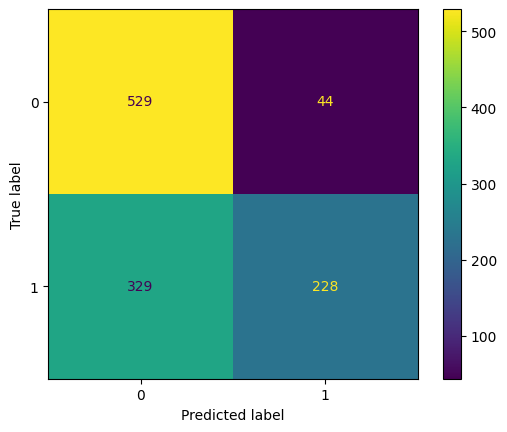

In [ ]:
cm_nb=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm_nb,display_labels=nb.classes_).plot()
plt.show

In [ ]:
### Metricas de medicion

### Matriz de confusión
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred))

#reporte de clasificacion
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.62      0.92      0.74       573
           1       0.84      0.41      0.55       557

    accuracy                           0.67      1130
   macro avg       0.73      0.67      0.64      1130
weighted avg       0.73      0.67      0.65      1130

